In [27]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
#Load the dataset
df = pd.read_csv(r"C:\Users\User\Downloads\mail_data.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
# fill null values with empty string
data = df.fillna('')

In [5]:
# use loc to allocate each category 'ham' and 'spam' o and 1
data.loc[data['Category'] == 'spam', 'Category',] = 0
data.loc[data['Category'] == 'ham', 'Category',] = 1

In [6]:
# define X and y
X = data['Message']
y = data['Category']

In [7]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [8]:
print(y)

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object


In [9]:
# split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [10]:
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

(5572,) (4457,) (1115,)
(5572,) (4457,) (1115,)


In [11]:
# transform text data into feature vectors for use in logistic regression
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [12]:
#Train the model using LogisticRegression
model = LogisticRegression()

In [13]:
# fit the model
model.fit(X_train_features, y_train)

LogisticRegression()

In [14]:
# prediction and accuracy on train data
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

In [15]:
print(accuracy_on_training_data)

0.9676912721561588


In [16]:
# precition and accuracy on test data
prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

In [17]:
print(accuracy_on_test_data)

0.9668161434977578


In [29]:
# Build prediction system with input feature
input_mail = ["This is the 2nd time we have tried 2 contact u..."]

input_data_features = feature_extraction.transform(input_mail)

prediction = model.predict(input_data_features)

print(prediction)

if prediction[0] == 1:
  print('Ham mail')
else:
  print('Spam mail')

[1]
Ham mail


In [30]:
#print classification report
print(classification_report(y_test, prediction_on_test_data))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86       155
           1       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



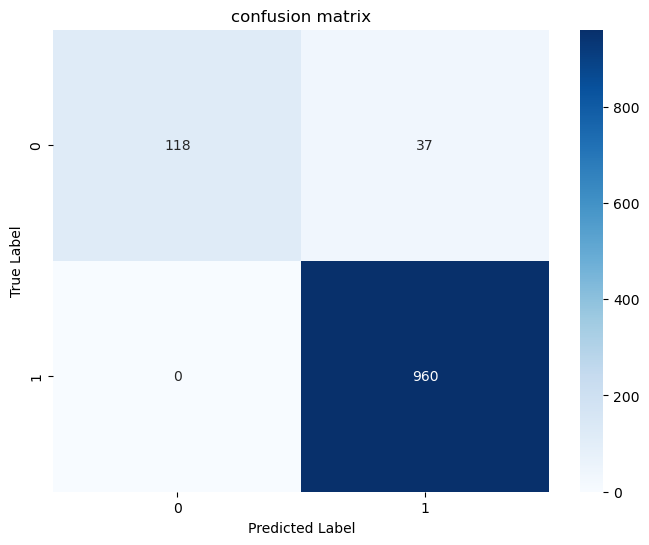

In [28]:
# plot confusion matrix
plt.figure(figsize = (8, 6))
cm = confusion_matrix(y_test, prediction_on_test_data)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('confusion matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()